In [25]:
# ==========================================
# 1. 필요한 라이브러리 불러오기
# ==========================================

# 한글 폰트 설치
!apt-get update -qq
!apt-get install -qq fonts-nanum -y # Added -y for non-interactive install

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

# Temporarily import matplotlib components to clear cache
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Clear font cache by deleting cache directory
!rm -rf ~/.cache/matplotlib

# Re-import matplotlib after cache clear and font install to ensure fresh state
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import time

# 난수 고정
np.random.seed(42)

# 그래프 기본 설정
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# Nanum 폰트 설정
# ==========================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

if os.path.exists(font_path):
    # Explicitly add font to fontManager
    fm.fontManager.addfont(font_path)

    # Reload font properties after adding and ensure it's registered
    font_prop = fm.FontProperties(fname=font_path)

    # Set global rcParams using the font's actual name
    plt.rcParams['font.family'] = font_prop.get_name()

    print(
        "사용 폰트 :",
        font_prop.get_name()
    )

else:

    print(
        "NanumGothic 폰트를 찾을 수 없습니다."
    )


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
사용 폰트 : NanumGothic


In [5]:
# ==========================================
# 2. 데이터 불러오기
# ==========================================

df = pd.read_csv(
    'final_dataset_line1_8_230101-241231.csv',
    encoding='utf-8-sig'
)

print('데이터 크기 :', df.shape)

df.head()

데이터 크기 : (3986800, 12)


,날짜,역명,호선,승차인원,시간,하차인원,요일,월,공휴일여부,기온,강수량,적설
0,2023-01-01,서울역,1호선,215,5,154,6,1,1,0.8,0.0,0.0
1,2023-01-01,시청,1호선,48,5,64,6,1,1,0.8,0.0,0.0
2,2023-01-01,종각,1호선,407,5,69,6,1,1,0.8,0.0,0.0
3,2023-01-01,종로3가,1호선,220,5,39,6,1,1,0.8,0.0,0.0
4,2023-01-01,종로5가,1호선,46,5,26,6,1,1,0.8,0.0,0.0


In [6]:
# ==========================================
# 3. 데이터 기본 정보 확인
# ==========================================

df.info()

print('\n결측치 개수')
print(df.isnull().sum())

print('\n중복 데이터 개수')
print(df.duplicated().sum())

print(
    '\n메모리 사용량(MB) :',
    round(
        df.memory_usage(deep=True).sum() / 1024**2,
        2
    )
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3986800 entries, 0 to 3986799
Data columns (total 12 columns):
 #   Column  Dtype  
---  ------  -----  
 0   날짜      object 
 1   역명      object 
 2   호선      object 
 3   승차인원    int64  
 4   시간      int64  
 5   하차인원    int64  
 6   요일      int64  
 7   월       int64  
 8   공휴일여부   int64  
 9   기온      float64
 10  강수량     float64
 11  적설      float64
dtypes: float64(3), int64(6), object(3)
memory usage: 365.0+ MB

결측치 개수
날짜       0
역명       0
호선       0
승차인원     0
시간       0
하차인원     0
요일       0
월        0
공휴일여부    0
기온       0
강수량      0
적설       0
dtype: int64

중복 데이터 개수
0

메모리 사용량(MB) : 1137.08


In [7]:
# ==========================================
# 4. 날짜 변수 생성
# ==========================================

df['날짜'] = pd.to_datetime(df['날짜'])

df = df.sort_values(
    '날짜'
).reset_index(drop=True)

df['일'] = df['날짜'].dt.day

print(
    df[['날짜', '월', '일']]
    .head()
)

          날짜  월  일
0 2023-01-01  1  1
1 2023-01-01  1  1
2 2023-01-01  1  1
3 2023-01-01  1  1
4 2023-01-01  1  1


In [8]:
# ==========================================
# 5. 범주형 변수 인코딩
# ==========================================

station_encoder = LabelEncoder()
line_encoder = LabelEncoder()

df['역명_encoded'] = station_encoder.fit_transform(
    df['역명']
)

df['호선_encoded'] = line_encoder.fit_transform(
    df['호선']
)

print(
    '역 개수 :',
    df['역명'].nunique()
)

print(
    '호선 개수 :',
    df['호선'].nunique()
)

역 개수 : 250
호선 개수 : 8


In [9]:
# ==========================================
# 6. Feature / Target 분리
# ==========================================

features = [
    '역명_encoded',
    '호선_encoded',
    '시간',
    '요일',
    '월',
    '일',
    '공휴일여부',
    '기온',
    '강수량',
    '적설'
]

X = df[features]

y = df['승차인원']

print(X.shape)
print(y.shape)

(3986800, 10)
(3986800,)


In [10]:
# ==========================================
# 7. 시계열 기반 데이터 분리
# ==========================================

split_idx = int(
    len(df) * 0.8
)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df[features]
y_train = train_df['승차인원']

X_test = test_df[features]
y_test = test_df['승차인원']

print(
    "Train :",
    X_train.shape
)

print(
    "Test :",
    X_test.shape
)

print(
    "\nTrain 기간"
)

print(
    train_df['날짜'].min()
)

print(
    train_df['날짜'].max()
)

print(
    "\nTest 기간"
)

print(
    test_df['날짜'].min()
)

print(
    test_df['날짜'].max()
)

Train : (3189440, 10)
Test : (797360, 10)

Train 기간
2023-01-01 00:00:00
2024-08-08 00:00:00

Test 기간
2024-08-08 00:00:00
2025-01-01 00:00:00


In [11]:
# ==========================================
# 8. RandomForest 모델 생성
# ==========================================

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=14,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
start = time.time()
model.fit(X_train, y_train)
end = time.time()

print('모델 학습 시간 :', round(end - start, 2), '초')

모델 학습 시간 : 183.26 초


In [12]:
# ==========================================
# 9. 예측 및 성능 평가 (Test Set 기준)
# ==========================================

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*50)
print("경량화 모델 검증 성능 (Test Set)")
print("="*50)
print("MAE      :", round(mae, 2))
print("RMSE     :", round(rmse, 2))
print("R2 Score :", round(r2, 4))

경량화 모델 검증 성능 (Test Set)
MAE      : 239.67
RMSE     : 477.84
R2 Score : 0.7955


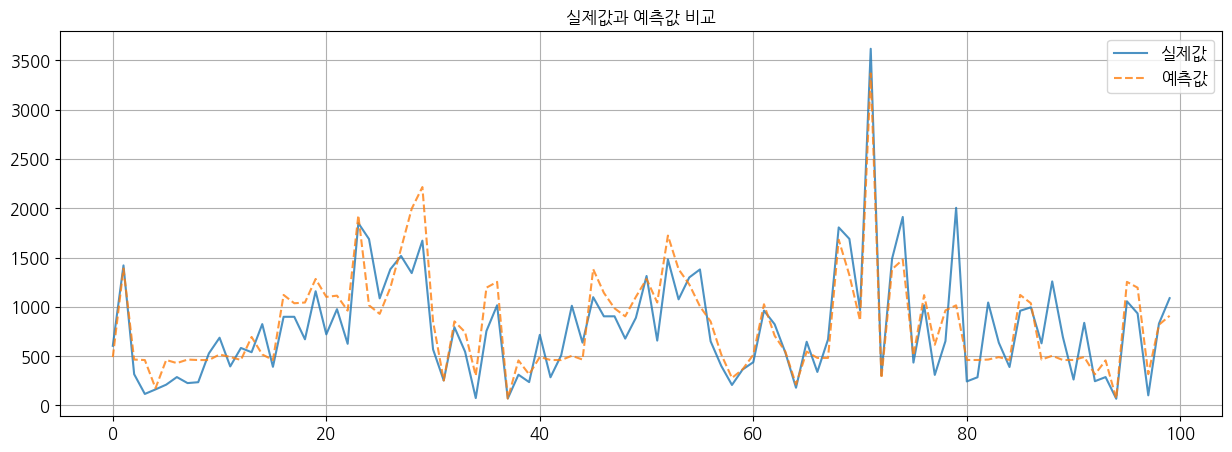

In [26]:
# ==========================================
# 10. 실제값 vs 예측값 시각화
# ==========================================

sample_size = 100

plt.figure(figsize=(15, 5))

plt.plot(
    y_test.values[:sample_size],
    label='실제값',
    alpha=0.8
)

plt.plot(
    y_pred[:sample_size],
    label='예측값',
    linestyle='--',
    alpha=0.8
)

plt.title(
    '실제값과 예측값 비교',
    fontproperties=font_prop
)

plt.legend(
    prop=font_prop
)

plt.grid()

plt.show()

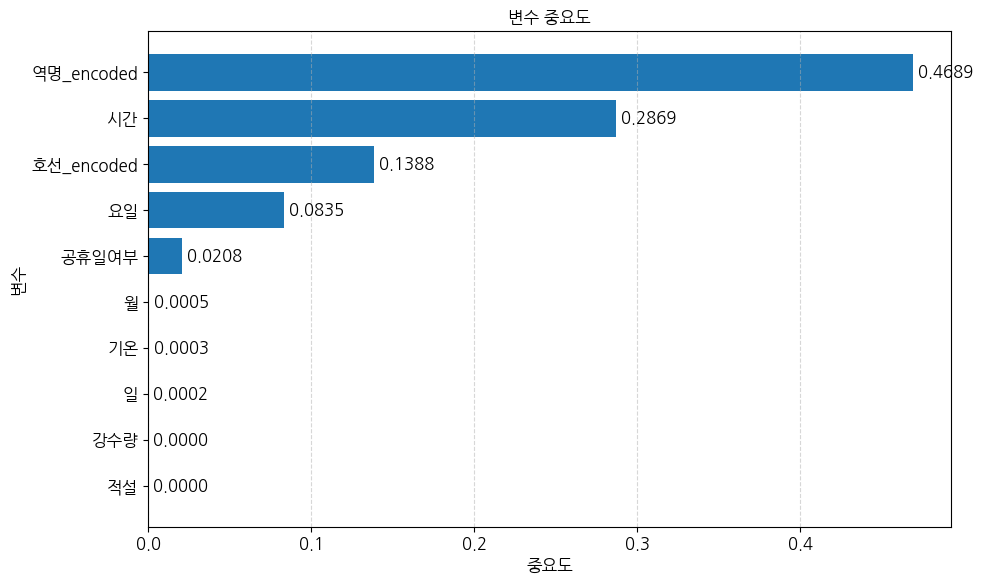

In [27]:
# ==========================================
# 11. 변수 중요도 시각화
# ==========================================


importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    importance_df['feature'],
    importance_df['importance']
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height()/2,
        f'{width:.4f}',
        va='center',
        fontproperties=font_prop
    )

plt.title(
    '변수 중요도',
    fontproperties=font_prop
)

plt.xlabel(
    '중요도',
    fontproperties=font_prop
)

plt.ylabel(
    '변수',
    fontproperties=font_prop
)

for label in plt.gca().get_yticklabels():
    label.set_fontproperties(font_prop)

for label in plt.gca().get_xticklabels():
    label.set_fontproperties(font_prop)

plt.gca().invert_yaxis()

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()


In [16]:
# ==========================================
# 12. 전체 데이터 재학습 및 저장
# ==========================================

print("전체 데이터 재학습 시작")

final_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=14,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

start = time.time()

final_model.fit(X, y)

end = time.time()

print(
    f"재학습 완료 : {round(end-start,2)}초"
)

# ==========================================
# 전체 데이터 성능 확인
# ==========================================

full_pred = final_model.predict(X)

full_mae = mean_absolute_error(
    y,
    full_pred
)

full_rmse = np.sqrt(
    mean_squared_error(
        y,
        full_pred
    )
)

full_r2 = r2_score(
    y,
    full_pred
)

print()
print("="*50)
print("전체 데이터 학습 성능")
print("="*50)

print(
    "MAE :",
    round(full_mae,2)
)

print(
    "RMSE :",
    round(full_rmse,2)
)

print(
    "R2 :",
    round(full_r2,4)
)

# ==========================================
# 모델 저장
# ==========================================

joblib.dump(
    final_model,
    'randomforest_boarding_model.pkl',
    compress=3
)

joblib.dump(
    station_encoder,
    'station_encoder.pkl'
)

joblib.dump(
    line_encoder,
    'line_encoder.pkl'
)

joblib.dump(
    features,
    'model_columns.pkl'
)

importance_df.to_csv(
    'boarding_feature_importance.csv',
    index=False,
    encoding='utf-8-sig'
)

# ==========================================
# 모델 크기 확인
# ==========================================

file_size_mb = (
    os.path.getsize(
        'randomforest_boarding_model.pkl'
    ) / (1024**2)
)

total_nodes = sum(
    tree.tree_.node_count
    for tree in final_model.estimators_
)

print()
print("="*50)
print(
    f"총 노드 수 : {total_nodes:,}"
)

print(
    f"모델 크기 : {file_size_mb:.2f} MB"
)

print("="*50)

배포용 최종 모델 재학습 시작...
재학습 완료 : 300.04초

최종 모델 참고 성능
MAE : 201.06
RMSE : 410.99
R2 : 0.8477

※ 전체 데이터 학습 성능 (참고용)

총 노드 수 : 2,884,284
모델 크기 : 64.64 MB
